# Parte teórica

Classifique as afirmações em Verdadeiro ou Falso, justifique as afirmativas falsas

1 - O espaço de cores RGB é amplamente utilizado pois é o mais intuitivo para seres humanos

In [ ]:
# F - O espaço de cor mais intuitivo para os seres humanos é o HSV

2 - Imagens vetoriais apresentam serrilhamento quando são ampliadas

In [ ]:
# F - o serrilhamento ocorre em imagens matriciais

3 - A lógica XOR aplicada em uma imagem detecta os pixels que mudaram de valor

In [ ]:
# V

4 - O código abaixo representa um circulo com 110px de altura, 128px de largura e rotacionado em 64 graus.

```<circle cx='110' cy='128' r='64' fill='red'/>```

In [ ]:
# F - cx e cy reoresentam a posição do centro e r representa o raio do circulo

5 - Algumas imagens podem ter um quarto canal chamado Alpha que representa a opacidade do pixel

In [ ]:
# V

# Parte prática

## Material de apoio

### Importações

```
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
```

### Manipulação de imagens

```
img = Image.open('nome.extensão')
img = np.array(Image.open('nome.extensão'))
img = img[:, :, :3]
img_pil = Image.fromarray(img_np)
img.save('nome.png')
Image.fromarray(img).save('nome_arquivo.extensao')
(l,c,p) = img.shape
```

### Greyscale

#### Algoritmo genérico, substituir o método escolhido
```
img_avg = np.zeros(shape=(l, c), dtype=np.uint8)
for i in range(l):
    for j in range(c):
        r = float(img_np[i, j, 0])
        g = float(img_np[i, j, 1])
        b = float(img_np[i, j, 2])
        
        img_avg[i, j] = (aplicar método)
```

#### Métodos: 

Lightness: $\frac{max(R,G,B)+min(R,G,B)}{2}$

Average: $\frac{R+G+B}{3}$

Luminosity: $0.2126 \cdot R + 0.7152 \cdot G + 0.0722 \cdot B$

### Escalonamento com nearest neighbor

```
ls, cs = l * sy, c * sx
mario_nn = np.zeros(shape=(ls, cs, p), dtype=np.uint8)

for i in range(ls):
    for j in range(cs):
        new_y = int(np.floor(i * (l / ls)))
        new_x = int(np.floor(j * (c / cs)))
        
        mario_nn[i, j] = mario[new_y, new_x]
```

### Cisalhamento

```
img_shear = np.zeros((int(l * (1.1 + cy)), int(c * (1.1 + cx)), p), dtype=np.uint8)
for i in range(l):
    for j in range(c):
        new_x = int(j + cx * i)
        new_y = int(cy * j + i)
        
        img_shear[new_y, new_x] = img[i, j]
```

### Imagem grayscale para imagem binária de 3 canais

``` 
bin = np.zeros(shape=(l,c,3),dtype=np.uint8)
    
for i in range(l):
    for j in range(c):
        if img[i,j] > thresh: 
            bin[i,j,:] = 255 
        else: 
            bin[i,j,:] = 0

```

**1 -** Importe as bibliotecas que serão usadas

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

**2 -** Abra as imagens horse.jpg e landscape.png, retire o canal alpha se necessário, exiba essas imagens e mostre o formato de cada uma

Dimensões da primeira imagem: (768, 1024, 3)
Dimensões da primeira imagem: (384, 512, 3)


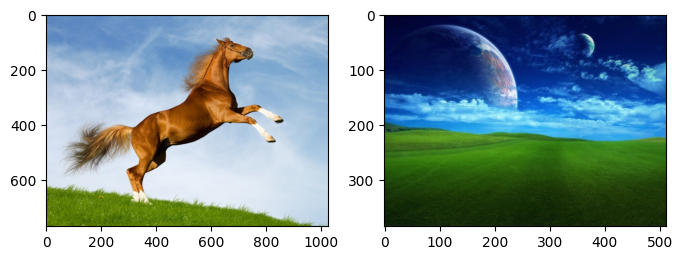

In [3]:
# Carrega as imagens, converte para um array NumPy e mantém apenas os três primeiros canais (RGB)
img1 = np.array(Image.open("horse.jpg"))[:, :, :3]  

img2 = np.array(Image.open("landscape.jpg"))[:, :, :3]  

# Define o tamanho da figura para exibição
plt.figure(figsize=(8, 8))  

# Adiciona a primeira imagem ao primeiro subplot (linha 1, coluna 1)
plt.subplot(2, 2, 1)  
plt.imshow(img1)  

# Adiciona a segunda imagem ao segundo subplot (linha 1, coluna 2)
plt.subplot(2, 2, 2)  
plt.imshow(img2)  

# Exibe as dimensões da primeira imagem (altura, largura, canais de cor)
print(f"Dimensões da primeira imagem: {img1.shape}")  

# Exibe as dimensões da primeira imagem (altura, largura, canais de cor)
print(f"Dimensões da primeira imagem: {img2.shape}")

**3 -** Crie uma função que realize o escalonamento de uma imagem que receba como parâmetro uma **imagem, sx e sy**, sendo sx e sy os fatores de escalonamento e **retorne a imagem escalonada**, em seguida aplique o escalonamento na imagem "landscape" para que fique do mesmo tamanho da imagem "horse". Exiba o resultado.

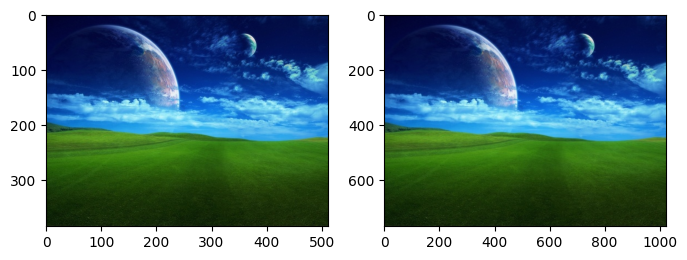

In [4]:
def escalonamento(img,sx,sy):
    # Obtém as dimensões da imagem original: altura (l), largura (c) e canais de cor (p)
    (l, c, p) = img.shape  

    # Calcula as novas dimensões da imagem escalonada
    (ls, cs) = (l * sy, c * sx)  

    # Cria uma nova matriz (imagem) com zeros e o mesmo número de canais da original
    sc_image = np.zeros(shape=(ls, cs, p), dtype=np.uint8)  

    # Percorre cada pixel da nova imagem escalonada
    for i in range(ls):  
        for j in range(cs):  
            # Mapeia as coordenadas da nova imagem para as coordenadas da imagem original
            new_y = int(np.floor(i * (l / ls)))  # Calcula a posição y na imagem original
            new_x = int(np.floor(j * (c / cs)))  # Calcula a posição x na imagem original
            
            # Atribui o valor do pixel correspondente da imagem original
            sc_image[i, j] = img[new_y, new_x]  

    return sc_image  # Retorna a imagem escalonada

# Aplica o escalonamento na imagem `img2`, dobrando o tamanho (fator 2x)
img2_esc = escalonamento(img2, 2, 2)  

# Cria uma figura para exibição
plt.figure(figsize=(8, 8))  

# Adiciona o subplot na posição 1 (linha 1, coluna 2)
plt.subplot(2, 2, 1)  
# Exibe a imagem original
plt.imshow(img2)

# Adiciona o subplot na posição 1 (linha 1, coluna 1)
plt.subplot(2, 2, 2)  
# Exibe a imagem escalonada 
plt.imshow(img2_esc)  

**4 -** Crie uma função para aplicar um método grayscale de sua escolha, que receba como **parâmetro uma imagem e retorne uma imagem em greyscale**. Aplique essa função na **imagem "horse"** e mostre o resultado.

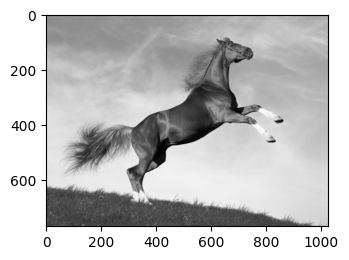

In [8]:
def grayscale(img):
    # Obtém as dimensões da imagem original: altura (l) e largura (c).
    (l,c,p) = img.shape

    # Cria uma matriz vazia para armazenar a imagem em escala de cinza
    img_grey = np.zeros(shape=(l, c), dtype=np.uint8)
    
    # Percorre todos os pixels da imagem.
    for i in range(l):  
        for j in range(c):  
            # Obtém os valores dos canais vermelho (R), verde (G) e azul (B).
            r = float(img[i, j, 0])  
            g = float(img[i, j, 1])  
            b = float(img[i, j, 2])  
            
            # Calcula a média dos canais para obter um tom de cinza.
            img_grey[i, j] = (r + g + b) / 3  

    return img_grey  # Retorna a imagem em tons de cinza.

# Converte a imagem `img1` para escala de cinza.
img1_cinza = grayscale(img1)  

# Cria uma figura para exibição.
plt.figure(figsize=(8, 8))  

# Adiciona o subplot na posição 1 (linha 1, coluna 1).
plt.subplot(2, 2, 1)  

# Exibe a imagem em escala de cinza com um mapa de cores apropriado.
plt.imshow(img1_cinza, cmap='gray')

**5 -** Crie uma função para transformar uma imagem grayscale em uma imagem binária, que receba como **parâmetro uma imagem e o threshhold** para realizar a operação e retorne uma imagem binária. Aplique essa função na imagem resultante da **etapa anterior com threshold de valor 135** e mostre o resultado.

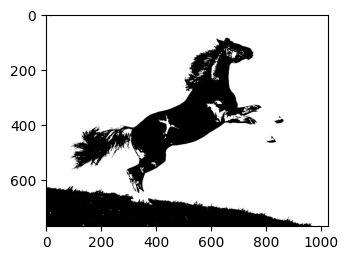

In [10]:
def gray_bin(img,thresh):
    # Obtém as dimensões da imagem (altura e largura)
    (l,c) = img.shape
    
    # Cria uma matriz para armazenar a imagem binária, mantendo 3 canais (RGB)
    bin = np.zeros(shape=(l, c, 3), dtype=np.uint8)  

    # Percorre todos os pixels da imagem
    for i in range(l):  
        for j in range(c):  
            # Se o pixel for maior que o limiar, torna branco (255, 255, 255)
            if img[i, j] > thresh:  
                bin[i, j, :] = 255  
            # Caso contrário, torna preto (0, 0, 0)
            else:  
                bin[i, j, :] = 0  

    return bin  # Retorna a imagem binarizada

# Converte a imagem em tons de cinza `img1_cinza` para uma imagem binária com limiar 135
img_bin = gray_bin(img1_cinza, 135)  

# Cria uma figura para exibição
plt.figure(figsize=(8, 8))  

# Adiciona o subplot na posição 1 (linha 1, coluna 1)
plt.subplot(2, 2, 1)  

# Exibe a imagem binarizada
plt.imshow(img_bin)

**6 -** Realize a operação NOT com a imagem da **etapa anterior** e mostre o resultado

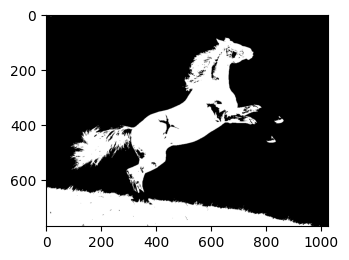

In [11]:
img_not = ~ img_bin

plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
plt.imshow(img_not)

**7 -** Aplique a imagem da **questão anterior como uma máscara (Lógica OR) com a imagem resultante do escalonamento na questão 3**. Mostre o resultado

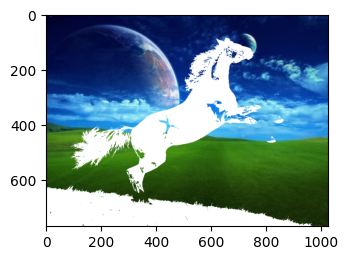

In [12]:
img_or = img_not | img2_esc

plt.figure(figsize=(8,8))
plt.subplot(2,2,1)
plt.imshow(img_or)

**8 -** Crie uma função para aplicar o cisalhamento em cima de uma imagem, que **recebe como parâmetro uma imagem, cx e cy**, sendo cx e cy os coeficientes do cisalhamento e retorne a imagem com o efeito aplicado. 
**Aplique a função na imagem anterior com cx=0.3 e cy=0.2**. Mostre o resultado.

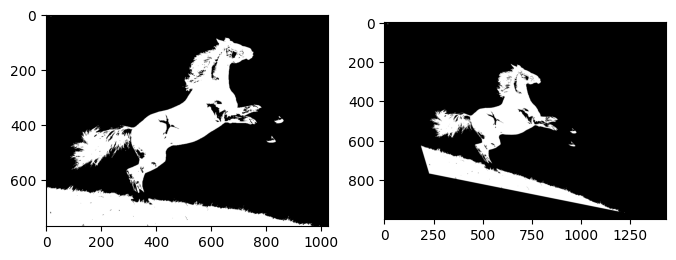

In [13]:
def cisalhamento(img,cx,cy):
    
    # Obtém as dimensões da imagem original: altura (l), largura (c) e canais de cor (p)
    (l, c, p) = img.shape  

    # Calcula as novas dimensões da imagem após o cisalhamento
    img_shear = np.zeros((int(l * (1.1 + cy)), int(c * (1.1 + cx)), p), dtype=np.uint8)

    # Percorre cada pixel da imagem original
    for i in range(l):  
        for j in range(c):  
            # Aplica a transformação de cisalhamento para obter novas coordenadas
            new_x = int(j + cx * i)  
            new_y = int(cy * j + i)  
            
            # Garante que os novos índices estejam dentro dos limites da nova imagem
            if 0 <= new_y < img_shear.shape[0] and 0 <= new_x < img_shear.shape[1]:
                img_shear[new_y, new_x] = img[i, j]  

    return img_shear  # Retorna a imagem cisalhada

# Aplica o cisalhamento na imagem `img_not` com fatores cx = 0.3 e cy = 0.2
img_cis = cisalhamento(img_not, 0.3, 0.2)  

# Cria uma figura para exibição
plt.figure(figsize=(8, 8))  

# Exibe a imagem original no primeiro subplot
plt.subplot(2, 2, 1)  
plt.imshow(img_not)  

# Exibe a imagem transformada no segundo subplot
plt.subplot(2, 2, 2)  
plt.imshow(img_cis)  

**9 -** Salve a imagem da questão anterior no disco com o nome "resultado.jpg"

In [14]:
Image.fromarray(img_cis).save("resultado.jpg")